# Grasp Detection with DepthAnythingV2 Small
## Cornell Grasping Dataset Evaluation

**Author:** Steyn Knollema (knollema@seas.upenn.edu)

This notebook implements the heuristic-based grasp detection pipeline using:
- **DepthAnythingV2 Small** for monocular depth estimation (replacing MiDaS)
- **Cornell Grasping Dataset** for evaluation
- **IoU-based accuracy metrics** comparing predictions to ground truth

### Pipeline Overview:
1. RGB Image → DepthAnythingV2 Small → Pseudo Depth
2. Edge Detection (Canny) + Depth Gradients (Sobel)
3. Saliency Fusion → Candidate Extraction → Filtering
4. Quality Scoring (Edge + Depth Gradient + CoG Proximity)
5. Compare with Cornell Ground Truth Rectangles

## 1. Installation and Imports

In [3]:
# Install required packages
# Run this cell first, then restart runtime if needed

!pip install -q torch torchvision opencv-python matplotlib numpy Pillow tqdm scipy transformers huggingface_hub opendatasets kaggle

print("✓ All packages installed!")

✓ All packages installed!


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Polygon
import matplotlib.patches as mpatches
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import os
import glob
import time
import json
import zipfile
import shutil
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print("✓ All libraries imported")

Using device: cuda
GPU: Tesla T4
✓ All libraries imported


## 2. Download Cornell Dataset from Kaggle

**Option A:** Use `opendatasets` (easiest - will prompt for credentials)  
**Option B:** Use Kaggle API (requires kaggle.json setup)  
**Option C:** Manual download from https://www.kaggle.com/datasets/oneoneliu/cornell-grasp

In [5]:
# ===== DOWNLOAD CORNELL DATASET FROM KAGGLE =====
# This cell will download the dataset automatically
# You'll need your Kaggle username and API key (from kaggle.com/account)

DATASET_DIR = './cornell_dataset'
KAGGLE_DATASET = 'oneoneliu/cornell-grasp'

def download_cornell_kaggle_opendatasets():
    """
    Download using opendatasets library (easiest method)
    Will prompt for Kaggle username and key if not set
    """
    import opendatasets as od

    print("="*80)
    print("DOWNLOADING CORNELL GRASPING DATASET FROM KAGGLE")
    print("="*80)
    print("\nYou'll need your Kaggle credentials:")
    print("1. Go to https://www.kaggle.com/account")
    print("2. Scroll to 'API' section")
    print("3. Click 'Create New Token' to download kaggle.json")
    print("4. Enter username and key when prompted below\n")

    # Download dataset
    od.download(f"https://www.kaggle.com/datasets/{KAGGLE_DATASET}")

    # Move to expected location
    downloaded_dir = './cornell-grasp'
    if os.path.exists(downloaded_dir):
        if os.path.exists(DATASET_DIR):
            shutil.rmtree(DATASET_DIR)
        shutil.move(downloaded_dir, DATASET_DIR)

    print(f"\n✓ Dataset downloaded to {DATASET_DIR}")
    return True

def download_cornell_kaggle_api():
    """
    Download using Kaggle API (requires kaggle.json in ~/.kaggle/)
    """
    import kaggle

    print("Downloading via Kaggle API...")

    os.makedirs(DATASET_DIR, exist_ok=True)

    # Download and unzip
    kaggle.api.dataset_download_files(
        KAGGLE_DATASET,
        path=DATASET_DIR,
        unzip=True
    )

    print(f"✓ Dataset downloaded to {DATASET_DIR}")
    return True

def setup_kaggle_credentials():
    """
    Interactive setup for Kaggle credentials on Windows
    """
    print("="*80)
    print("KAGGLE CREDENTIALS SETUP")
    print("="*80)

    # Check if credentials already exist
    kaggle_dir = os.path.join(os.path.expanduser('~'), '.kaggle')
    kaggle_json = os.path.join(kaggle_dir, 'kaggle.json')

    if os.path.exists(kaggle_json):
        print(f"✓ Kaggle credentials found at {kaggle_json}")
        return True

    print("\nNo kaggle.json found. Let's set it up!")
    print("\n1. Go to https://www.kaggle.com/account")
    print("2. Scroll down to 'API' section")
    print("3. Click 'Create New Token'")
    print("4. This downloads kaggle.json\n")

    # Get credentials from user
    username = input("Enter your Kaggle username: ").strip()
    key = input("Enter your Kaggle API key: ").strip()

    if not username or not key:
        print("❌ Invalid credentials. Please try again.")
        return False

    # Create kaggle directory and json file
    os.makedirs(kaggle_dir, exist_ok=True)

    credentials = {"username": username, "key": key}
    with open(kaggle_json, 'w') as f:
        json.dump(credentials, f)

    # Set permissions (important on Linux/Mac, Windows ignores this)
    try:
        os.chmod(kaggle_json, 0o600)
    except:
        pass

    print(f"\n✓ Credentials saved to {kaggle_json}")
    return True

def check_dataset_exists():
    """Check if dataset is already downloaded"""
    if not os.path.exists(DATASET_DIR):
        return False

    # Look for image files
    patterns = [
        os.path.join(DATASET_DIR, '**', 'pcd*r.png'),
        os.path.join(DATASET_DIR, '**', '*.png'),
    ]

    for pattern in patterns:
        files = glob.glob(pattern, recursive=True)
        if len(files) > 10:
            print(f"✓ Dataset already exists with {len(files)} images")
            return True

    return False

print("Cornell Dataset Downloader Ready")
print("Run the next cell to download the dataset")

Cornell Dataset Downloader Ready
Run the next cell to download the dataset


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# ===== DOWNLOAD THE DATASET =====
# This will prompt for your Kaggle credentials if needed

if check_dataset_exists():
    print("Dataset already downloaded!")
else:
    print("Dataset not found. Starting download...\n")

    # Try opendatasets first (easiest)
    try:
        download_cornell_kaggle_opendatasets()
    except Exception as e:
        print(f"\nopendatasets failed: {e}")
        print("\nTrying Kaggle API method...\n")

        # Setup credentials and try API
        if setup_kaggle_credentials():
            try:
                download_cornell_kaggle_api()
            except Exception as e2:
                print(f"\nKaggle API also failed: {e2}")
                print("\n" + "="*80)
                print("MANUAL DOWNLOAD REQUIRED")
                print("="*80)
                print("\n1. Go to: https://www.kaggle.com/datasets/oneoneliu/cornell-grasp")
                print("2. Click 'Download' button")
                print("3. Extract the zip file")
                print(f"4. Move contents to: {os.path.abspath(DATASET_DIR)}")
                print("5. Re-run this cell to verify")

Dataset not found. Starting download...

DOWNLOADING CORNELL GRASPING DATASET FROM KAGGLE

You'll need your Kaggle credentials:
1. Go to https://www.kaggle.com/account
2. Scroll to 'API' section
3. Click 'Create New Token' to download kaggle.json
4. Enter username and key when prompted below

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: steynknollema
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/oneoneliu/cornell-grasp


100%|██████████| 4.85G/4.85G [01:39<00:00, 52.6MB/s]




✓ Dataset downloaded to ./cornell_dataset


In [8]:
# ===== VERIFY DATASET STRUCTURE =====

def explore_dataset(root_dir):
    """Explore and display dataset structure"""
    print("\n" + "="*80)
    print("DATASET STRUCTURE")
    print("="*80)

    if not os.path.exists(root_dir):
        print(f"❌ Directory not found: {root_dir}")
        return

    # Count files by type
    rgb_files = glob.glob(os.path.join(root_dir, '**', '*r.png'), recursive=True)
    depth_files = glob.glob(os.path.join(root_dir, '**', '*d.tiff'), recursive=True)
    grasp_files = glob.glob(os.path.join(root_dir, '**', '*cpos.txt'), recursive=True)

    print(f"\nRoot directory: {os.path.abspath(root_dir)}")
    print(f"\nFile counts:")
    print(f"  RGB images (*r.png):     {len(rgb_files)}")
    print(f"  Depth images (*d.tiff):  {len(depth_files)}")
    print(f"  Grasp labels (*cpos.txt): {len(grasp_files)}")

    # Show folder structure
    print(f"\nFolder structure:")
    for item in sorted(os.listdir(root_dir))[:15]:
        item_path = os.path.join(root_dir, item)
        if os.path.isdir(item_path):
            sub_count = len(os.listdir(item_path))
            print(f"  📁 {item}/ ({sub_count} files)")
        else:
            print(f"  📄 {item}")

    if len(os.listdir(root_dir)) > 15:
        print(f"  ... and {len(os.listdir(root_dir)) - 15} more items")

    # Show sample files
    if rgb_files:
        print(f"\nSample RGB files:")
        for f in rgb_files[:3]:
            print(f"  {f}")

    return len(rgb_files), len(grasp_files)

rgb_count, grasp_count = explore_dataset(DATASET_DIR)

if rgb_count > 0 and grasp_count > 0:
    print("\n✓ Dataset is ready for use!")
else:
    print("\n⚠️ Dataset may be incomplete or in wrong location")


DATASET STRUCTURE

Root directory: /content/cornell_dataset

File counts:
  RGB images (*r.png):     896
  Depth images (*d.tiff):  885
  Grasp labels (*cpos.txt): 885

Folder structure:
  📁 01/ (500 files)
  📁 02/ (500 files)
  📁 03/ (500 files)
  📁 04/ (500 files)
  📁 05/ (500 files)
  📁 06/ (500 files)
  📁 07/ (500 files)
  📁 08/ (500 files)
  📁 09/ (250 files)
  📁 10/ (175 files)
  📁 backgrounds/ (11 files)

Sample RGB files:
  ./cornell_dataset/01/pcd0115r.png
  ./cornell_dataset/01/pcd0145r.png
  ./cornell_dataset/01/pcd0170r.png

✓ Dataset is ready for use!


## 3. Configuration Parameters

In [9]:
# ===== GLOBAL RANKING PARAMETERS =====
# NOTE: The main pipeline parameters are now in the cell that defines the GraspDetector
# These parameters below are kept for backwards compatibility with legacy detectors

EDGE_WEIGHT = 0.01         # Edge quality weight (legacy)
DEPTH_WEIGHT = 0.04        # Depth gradient weight (legacy)
COG_WEIGHT = 0.95          # CoG proximity weight (legacy)

# Verify weights sum to 1.0
total_weight = EDGE_WEIGHT + DEPTH_WEIGHT + COG_WEIGHT
assert abs(total_weight - 1.0) < 0.01, f"Weights must sum to 1.0, got {total_weight}"

# ===== FILTERING PARAMETERS (for legacy HeuristicGraspDetector) =====
BOUNDARY_MARGIN = 50        # Pixels from image boundary
DEPTH_MIN = 0.15            # Minimum normalized depth
DEPTH_MAX = 0.90            # Maximum normalized depth
TEXTURE_THRESHOLD = 5       # Minimum local std dev
TEXTURE_PATCH_SIZE = 20     # Patch size for texture check
MIN_NEIGHBORS = 3           # Minimum nearby features
NEIGHBOR_RADIUS = 40        # Radius for neighbor check

# ===== EVALUATION PARAMETERS =====
IOU_THRESHOLD = 0.25        # IoU threshold for grasp success (Cornell standard)
ANGLE_THRESHOLD = 30        # Degrees threshold for angle match

# ===== VISUALIZATION PARAMETERS =====
SHOW_TOP_PERCENT = 10       # Show top N% of grasps
COLORMAP = 'RdYlGn_r'       # Colormap for quality visualization

print("="*80)
print("CONFIGURATION PARAMETERS")
print("="*80)
print("NOTE: Main pipeline params are in the GraspDetector cell (cell 22)")
print("-"*80)
print(f"Legacy Weights: Edge={EDGE_WEIGHT*100:.1f}%, Depth={DEPTH_WEIGHT*100:.1f}%, CoG={COG_WEIGHT*100:.1f}%")
print(f"IoU Threshold:       {IOU_THRESHOLD}")
print(f"Angle Threshold:     {ANGLE_THRESHOLD}°")
print("="*80)


CONFIGURATION PARAMETERS
NOTE: Main pipeline params are in the GraspDetector cell (cell 22)
--------------------------------------------------------------------------------
Legacy Weights: Edge=1.0%, Depth=4.0%, CoG=95.0%
IoU Threshold:       0.25
Angle Threshold:     30°


## 4. DepthAnythingV2 Small Model Setup

In [10]:
class DepthAnythingV2:
    """DepthAnythingV2 Small wrapper for monocular depth estimation"""

    def __init__(self, model_size='small', device='cuda'):
        self.device = device
        self.model_size = model_size
        self.model = None
        self.processor = None
        self.load_time = 0

    def load_model(self):
        """Load the DepthAnythingV2 model from HuggingFace"""
        start_time = time.time()

        try:
            from transformers import AutoImageProcessor, AutoModelForDepthEstimation

            model_ids = {
                'small': 'depth-anything/Depth-Anything-V2-Small-hf',
                'base': 'depth-anything/Depth-Anything-V2-Base-hf',
                'large': 'depth-anything/Depth-Anything-V2-Large-hf'
            }

            model_id = model_ids.get(self.model_size, model_ids['small'])
            print(f"Loading {model_id}...")

            self.processor = AutoImageProcessor.from_pretrained(model_id)
            self.model = AutoModelForDepthEstimation.from_pretrained(model_id)
            self.model.to(self.device)
            self.model.eval()

            self.load_time = time.time() - start_time
            print(f"✓ Model loaded in {self.load_time:.2f}s")

        except Exception as e:
            print(f"Error loading model: {e}")
            print("Falling back to MiDaS...")
            self._load_midas_fallback()

    def _load_midas_fallback(self):
        """Fallback to MiDaS if DepthAnything fails"""
        start_time = time.time()

        self.model = torch.hub.load('intel-isl/MiDaS', 'DPT_Hybrid', pretrained=True)
        self.model.to(self.device)
        self.model.eval()

        midas_transforms = torch.hub.load('intel-isl/MiDaS', 'transforms')
        self.transform = midas_transforms.dpt_transform
        self.processor = None

        self.load_time = time.time() - start_time
        print(f"✓ MiDaS fallback loaded in {self.load_time:.2f}s")

    @torch.no_grad()
    def predict(self, image: np.ndarray) -> Tuple[np.ndarray, float]:
        """Predict depth from RGB image"""
        start_time = time.time()

        h, w = image.shape[:2]

        if self.processor is not None:
            # HuggingFace DepthAnything path
            pil_image = Image.fromarray(image)
            inputs = self.processor(images=pil_image, return_tensors="pt")
            inputs = {k: v.to(self.device) for k, v in inputs.items()}

            outputs = self.model(**inputs)
            depth = outputs.predicted_depth

            depth = F.interpolate(
                depth.unsqueeze(1),
                size=(h, w),
                mode='bicubic',
                align_corners=False
            ).squeeze().cpu().numpy()
        else:
            # MiDaS fallback path
            input_batch = self.transform(image).to(self.device)
            prediction = self.model(input_batch)

            depth = F.interpolate(
                prediction.unsqueeze(1),
                size=(h, w),
                mode='bicubic',
                align_corners=False
            ).squeeze().cpu().numpy()

        # Normalize to [0, 1]
        depth = (depth - depth.min()) / (depth.max() - depth.min() + 1e-8)

        inference_time = (time.time() - start_time) * 1000

        return depth.astype(np.float32), inference_time

print("✓ DepthAnythingV2 class defined")

✓ DepthAnythingV2 class defined


In [11]:
# Initialize and load the depth model
print("Initializing DepthAnythingV2 Small...")
depth_model = DepthAnythingV2(model_size='small', device=str(device))
depth_model.load_model()

Initializing DepthAnythingV2 Small...
Loading depth-anything/Depth-Anything-V2-Small-hf...


preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/99.2M [00:00<?, ?B/s]

✓ Model loaded in 24.60s


## 5. Cornell Grasping Dataset Handler

In [12]:
class CornellGraspDataset:
    """Cornell Grasping Dataset handler"""

    def __init__(self, data_dir: str = './cornell_dataset'):
        self.data_dir = data_dir
        self.samples = []

    def load_dataset(self, max_samples: Optional[int] = None) -> List[Dict]:
        """Load dataset samples"""
        self.samples = []

        # Find all RGB images with multiple patterns
        patterns = [
            os.path.join(self.data_dir, '**', 'pcd*r.png'),
            os.path.join(self.data_dir, '**', '*r.png'),
            os.path.join(self.data_dir, '*', 'pcd*r.png'),
        ]

        rgb_files = []
        for pattern in patterns:
            rgb_files.extend(glob.glob(pattern, recursive=True))
        rgb_files = list(set(rgb_files))  # Remove duplicates

        print(f"Found {len(rgb_files)} RGB images")

        for rgb_path in sorted(rgb_files):
            # Get base path (remove 'r.png')
            if rgb_path.endswith('r.png'):
                base = rgb_path[:-5]
            else:
                continue

            # Find grasp file
            grasp_path = base + 'cpos.txt'
            if not os.path.exists(grasp_path):
                continue

            # Load grasps
            grasps = self._load_grasp_rectangles(grasp_path)
            if not grasps:
                continue

            # Depth is optional
            depth_path = base + 'd.tiff'
            if not os.path.exists(depth_path):
                depth_path = None

            self.samples.append({
                'rgb_path': rgb_path,
                'depth_path': depth_path,
                'grasps': grasps,
                'id': os.path.basename(base)
            })

            if max_samples and len(self.samples) >= max_samples:
                break

        print(f"✓ Loaded {len(self.samples)} samples with ground truth grasps")
        return self.samples

    def _load_grasp_rectangles(self, filepath: str) -> List[Dict]:
        """Load grasp rectangles from file (4 corner points per grasp)"""
        grasps = []

        try:
            with open(filepath, 'r') as f:
                lines = f.readlines()

            # Each grasp is 4 consecutive lines
            for i in range(0, len(lines) - 3, 4):
                corners = []
                valid = True

                for j in range(4):
                    try:
                        parts = lines[i + j].strip().split()
                        if len(parts) >= 2:
                            x, y = float(parts[0]), float(parts[1])
                            if not (np.isnan(x) or np.isnan(y)):
                                corners.append([x, y])
                            else:
                                valid = False
                                break
                        else:
                            valid = False
                            break
                    except:
                        valid = False
                        break

                if valid and len(corners) == 4:
                    corners = np.array(corners)

                    # Calculate center
                    center = corners.mean(axis=0)

                    # Calculate angle
                    dx = corners[1, 0] - corners[0, 0]
                    dy = corners[1, 1] - corners[0, 1]
                    angle = np.arctan2(dy, dx)

                    # Calculate dimensions
                    width = np.linalg.norm(corners[1] - corners[0])
                    height = np.linalg.norm(corners[2] - corners[1])

                    grasps.append({
                        'corners': corners,
                        'center': center,
                        'angle': angle,
                        'angle_deg': np.degrees(angle),
                        'width': width,
                        'height': height
                    })
        except Exception as e:
            pass

        return grasps

print("✓ CornellGraspDataset class defined")

✓ CornellGraspDataset class defined


In [13]:
# Load dataset
dataset = CornellGraspDataset(DATASET_DIR)
samples = dataset.load_dataset(max_samples=800)  # Limit for speed

if not samples:
    print("\n⚠️ No samples found. Please check dataset path.")
    print(f"Expected location: {os.path.abspath(DATASET_DIR)}")

Found 896 RGB images
✓ Loaded 800 samples with ground truth grasps


# Helper fucntions that i need to use otherwise CoG doesn't work


## 6. Heuristic Grasp Detection Pipeline

In [14]:
@dataclass
class GraspCandidate:
    """Represents a predicted grasp candidate"""
    x: int
    y: int
    angle: float
    width: float
    height: float = 20.0
    edge_quality: float = 0.0
    depth_quality: float = 0.0
    cog_quality: float = 0.0
    combined_quality: float = 0.0

    def get_corners(self) -> np.ndarray:
        """Get rectangle corners for IoU calculation"""
        cos_a = np.cos(self.angle)
        sin_a = np.sin(self.angle)

        corners = []
        for dx, dy in [(-self.width/2, -self.height/2),
                       (self.width/2, -self.height/2),
                       (self.width/2, self.height/2),
                       (-self.width/2, self.height/2)]:
            x = self.x + dx * cos_a - dy * sin_a
            y = self.y + dx * sin_a + dy * cos_a
            corners.append([x, y])

        return np.array(corners)


class HeuristicGraspDetector:
    """Heuristic-based grasp detection"""

    def __init__(self, edge_weight=0.20, depth_weight=0.40, cog_weight=0.40):
        self.edge_weight = edge_weight
        self.depth_weight = depth_weight
        self.cog_weight = cog_weight

    def detect(self, rgb: np.ndarray, depth: np.ndarray,
               num_grasps: int = 10) -> Tuple[List[GraspCandidate], Dict]:
        """Detect grasp candidates"""
        h, w = rgb.shape[:2]
        debug = {}

        # Edge Detection
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        edges_normalized = edges.astype(np.float32) / 255.0
        debug['edges'] = edges_normalized

        # Depth Gradients
        depth_x = cv2.Sobel(depth, cv2.CV_64F, 1, 0, ksize=5)
        depth_y = cv2.Sobel(depth, cv2.CV_64F, 0, 1, ksize=5)
        depth_grad = np.sqrt(depth_x**2 + depth_y**2)
        depth_grad_normalized = (depth_grad - depth_grad.min()) / (depth_grad.max() - depth_grad.min() + 1e-8)
        debug['depth_grad'] = depth_grad_normalized

        # Saliency Fusion
        saliency = 0.3 * edges_normalized + 0.7 * depth_grad_normalized.astype(np.float32)
        saliency = cv2.GaussianBlur(saliency, (15, 15), 0)
        debug['saliency'] = saliency

        # Local Maxima
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
        local_max = cv2.dilate(saliency, kernel, iterations=1)
        local_max_mask = (saliency == local_max) & (saliency > np.percentile(saliency, 70))

        y_coords, x_coords = np.where(local_max_mask)

        # Initial Candidates
        candidates = [{'x': x, 'y': y, 'score': saliency[y, x]}
                     for x, y in zip(x_coords, y_coords)]

        # Filtering
        filtered = []
        for cand in candidates:
            x, y = cand['x'], cand['y']

            if x < BOUNDARY_MARGIN or x > w - BOUNDARY_MARGIN:
                continue
            if y < BOUNDARY_MARGIN or y > h - BOUNDARY_MARGIN:
                continue
            if depth[y, x] < DEPTH_MIN or depth[y, x] > DEPTH_MAX:
                continue

            patch = gray[max(0, y-10):y+10, max(0, x-10):x+10]
            if patch.size > 0 and np.std(patch) < TEXTURE_THRESHOLD:
                continue

            filtered.append(cand)

        if not filtered:
            filtered = [{'x': w//2, 'y': h//2, 'score': 0.5}]

        # CoG Estimation
        binary = ((depth > 0.1) & (depth < 0.9)).astype(np.uint8) * 255
        moments = cv2.moments(binary)
        if moments["m00"] != 0:
            cog_x = int(moments["m10"] / moments["m00"])
            cog_y = int(moments["m01"] / moments["m00"])
        else:
            cog_x, cog_y = w // 2, h // 2

        debug['cog'] = (cog_x, cog_y)

        # Quality Scoring
        max_dist = max(np.sqrt((c['x'] - cog_x)**2 + (c['y'] - cog_y)**2)
                      for c in filtered) if filtered else 1

        grasp_candidates = []
        for c in filtered:
            x, y = c['x'], c['y']

            edge_q = edges_normalized[y, x]
            depth_q = depth_grad_normalized[y, x]
            dist = np.sqrt((x - cog_x)**2 + (y - cog_y)**2)
            cog_q = 1 - (dist / max(max_dist, 1))

            combined = (self.edge_weight * edge_q +
                       self.depth_weight * depth_q +
                       self.cog_weight * cog_q)

            # Estimate angle from depth gradient
            gx = depth_x[y, x]
            gy = depth_y[y, x]
            angle = np.arctan2(gy, gx) + np.pi/2

            grasp_candidates.append(GraspCandidate(
                x=x, y=y, angle=angle, width=60,
                edge_quality=edge_q, depth_quality=depth_q,
                cog_quality=cog_q, combined_quality=combined
            ))

        grasp_candidates.sort(key=lambda g: g.combined_quality, reverse=True)

        return grasp_candidates[:num_grasps], debug

print("✓ HeuristicGraspDetector class defined")

✓ HeuristicGraspDetector class defined


6.5 improved saliency map and CoG


6.75 Improved gradient approach for grasping direction


In [15]:
# ==========================================
# GRASP DETECTION PIPELINE FROM app_working.py
# ==========================================
# This is the exact method from app_working.py
# DO NOT MODIFY - Any changes should be made in app_working.py first
# ==========================================

import cv2
import numpy as np

# ==========================================
# CONFIGURABLE PARAMETERS
# Set these before running the evaluation
# ==========================================

# Weights for quality scoring (must sum to ~1.0)
W_EDGE = 0.20              # Edge quality weight
W_DEPTH = 0.40             # Depth gradient weight
W_COG = 0.40               # CoG proximity weight

# Masking parameters
DEPTH_PERCENTILE = 60      # Depth percentile cutoff for background (0-100)

# Ray casting parameters
RAY_ALGORITHM = "Direct Line with CoG Boost"  # Options: "Through CoG", "Direct Line with CoG Boost"
COG_BOOST_VALUE = 2.0      # CoG boost (only used if RAY_ALGORITHM == "Direct Line with CoG Boost")
GRADIENT_SOURCE = "Contour Direction (80px avg)"  # Options: "Contour Direction (80px avg)", "Depth Gradients", "Image Edges", "Radial from Center"

# Filtering parameters
MIN_GRASP_LENGTH = 5    # Minimum grasp width in pixels
MAX_GRASP_LENGTH = 1000    # Maximum grasp width in pixels

# Output parameters
NUM_OUTPUT_GRASPS = 10     # Number of grasps to output
CANDIDATE_MULTIPLIER = 3   # Multiplier for candidate sampling (num_grasps * multiplier candidates evaluated)

print("="*80)
print("PIPELINE PARAMETERS (app_working.py method)")
print("="*80)
print(f"Weights: Edge={W_EDGE:.2f}, Depth={W_DEPTH:.2f}, CoG={W_COG:.2f}")
print(f"Depth Percentile: {DEPTH_PERCENTILE}")
print(f"Ray Algorithm: {RAY_ALGORITHM}")
print(f"Grasp Length Range: [{MIN_GRASP_LENGTH}, {MAX_GRASP_LENGTH}]")
print(f"Output Grasps: {NUM_OUTPUT_GRASPS}, Candidate Multiplier: {CANDIDATE_MULTIPLIER}")
print("="*80)

# ==========================================
# CLASSES (exact copy from app_working.py)
# ==========================================

class Candidate:
    def __init__(self, x, y, angle, w, h=20.0, eq=0.0, dq=0.0, cq=0.0, comb=0.0, l=0.0):
        self.x = int(x)
        self.y = int(y)
        self.angle = angle
        self.width = float(w)
        self.height = h
        self.edge_quality = float(eq)
        self.depth_quality = float(dq)
        self.cog_quality = float(cq)
        self.combined_quality = float(comb)
        self.line_length = float(l)

    def get_corners(self):
        c = np.cos(self.angle)
        s = np.sin(self.angle)
        w, h = self.width, self.height

        # local corners
        pts = [(-w/2, -h/2), (w/2, -h/2), (w/2, h/2), (-w/2, h/2)]

        res = []
        for dx, dy in pts:
            px = self.x + dx * c - dy * s
            py = self.y + dx * s + dy * c
            res.append([px, py])

        return np.array(res)

class GraspDetector:
    def __init__(self, w_e, w_d, w_c):
        self.we = w_e
        self.wd = w_d
        self.wc = w_c

    def _ray_cast(self, mask, start, vec_x, vec_y, contour=None, mode="Depth Gradients", limit=500):
        # This handles the ray casting logic.
        # Supports multiple modes for direction finding.
        h, w = mask.shape
        gx, gy = start

        # Determine direction (dx, dy)
        dx, dy = 1.0, 0.0 # defaults

        if mode == "Contour Direction (80px avg)":
            if contour is not None:
                pts = contour.reshape(-1, 2)

                # get nearest point index
                dists = np.sqrt((pts[:, 0] - gx)**2 + (pts[:, 1] - gy)**2)
                idx = np.argmin(dists)

                # grab a segment ~80px
                n_pts = min(40, len(pts) // 4)
                half = n_pts // 2

                s_idx = (idx - half) % len(pts)
                e_idx = (idx + half) % len(pts)

                if s_idx < e_idx:
                    seg = pts[s_idx:e_idx+1]
                else:
                    seg = np.vstack([pts[s_idx:], pts[:e_idx+1]])

                if len(seg) > 2:
                    # PCA approach for tangent
                    xs = seg[:, 0]
                    ys = seg[:, 1]
                    mx, my = np.mean(xs), np.mean(ys)

                    x_c = xs - mx
                    y_c = ys - my

                    Sxx = np.sum(x_c * x_c)
                    Sxy = np.sum(x_c * y_c)
                    Syy = np.sum(y_c * y_c)

                    if Sxx + Syy > 1e-6:
                        tr = Sxx + Syy
                        det = Sxx * Syy - Sxy * Sxy
                        l1 = tr/2 + np.sqrt(max(0, (tr/2)**2 - det))

                        if abs(Sxy) > 1e-6:
                            tx = l1 - Syy
                            ty = Sxy
                        elif abs(Sxx - l1) > 1e-6:
                            tx = Sxy
                            ty = l1 - Sxx
                        else:
                            tx = seg[-1, 0] - seg[0, 0]
                            ty = seg[-1, 1] - seg[0, 1]

                        l = np.sqrt(tx**2 + ty**2)
                        if l > 1e-6:
                            tx /= l; ty /= l
                            # rotate 90 deg for normal
                            dx = -ty
                            dy = tx
                        else:
                            dx, dy = 1.0, 0.0
                    else:
                        dx, dy = 1.0, 0.0
                else:
                    # not enough points, simple diff
                    if len(seg) >= 2:
                        tx = seg[-1, 0] - seg[0, 0]
                        ty = seg[-1, 1] - seg[0, 1]
                        l = np.sqrt(tx**2 + ty**2)
                        if l > 1e-6:
                            tx /= l; ty /= l
                            dx, dy = -ty, tx

        elif mode == "Depth Gradients":
            # use precalculated gradients passed as args
            if 0 <= gy < vec_y.shape[0] and 0 <= gx < vec_x.shape[1]:
                val_x = vec_x[gy, gx]
                val_y = vec_y[gy, gx]
            else:
                # bounds check failed, sample area
                ks = 3
                val_x = np.mean(vec_x[max(0, gy-ks):min(h, gy+ks+1), max(0, gx-ks):min(w, gx+ks+1)])
                val_y = np.mean(vec_y[max(0, gy-ks):min(h, gy+ks+1), max(0, gx-ks):min(w, gx+ks+1)])

            lenght = np.sqrt(val_x**2 + val_y**2)
            if lenght < 1e-6:
                # radial fallback
                dx = gx - w // 2
                dy = gy - h // 2
                lenght = np.sqrt(dx**2 + dy**2)
                if lenght > 1e-6: dx /= lenght; dy /= lenght
            else:
                # perpendicular
                dx = -val_y / lenght
                dy = val_x / lenght

        elif mode == "Image Edges":
             # similar to depth but on rgb edges
             ks = 5
             ymin, ymax = max(0, gy - ks), min(h, gy + ks + 1)
             xmin, xmax = max(0, gx - ks), min(w, gx + ks + 1)

             local = mask[ymin:ymax, xmin:xmax].astype(np.float32)
             if local.size > 0:
                 lx = cv2.Sobel(local, cv2.CV_64F, 1, 0, ksize=3)
                 ly = cv2.Sobel(local, cv2.CV_64F, 0, 1, ksize=3)

                 cy = min(ks, gy - ymin)
                 cx = min(ks, gx - xmin)

                 if cy < ly.shape[0] and cx < lx.shape[1]:
                     vx, vy = lx[cy, cx], ly[cy, cx]
                 else:
                     vx, vy = np.mean(lx), np.mean(ly)

                 l = np.sqrt(vx**2 + vy**2)
                 if l > 1e-6:
                     dx = -vy / l
                     dy = vx / l

        elif mode == "Radial from Center":
            cx, cy = w//2, h//2
            dx = gx - cx
            dy = gy - cy
            l = np.sqrt(dx**2 + dy**2)
            if l > 1e-6:
                dx /= l
                dy /= l

        # Trace both ways
        x1, y1 = self._trace_line(mask, gx, gy, dx, dy, limit)
        x2, y2 = self._trace_line(mask, gx, gy, -dx, -dy, limit)

        full_dist = np.sqrt((x1-x2)**2 + (y1-y2)**2)
        return x1, y1, x2, y2, full_dist

    def _cog_ray(self, mask, gp, cog, limit=500):
        gx, gy = gp
        cx, cy = cog

        # Vector from COG to Grasp Point
        vx = gx - cx
        vy = gy - cy

        dist = np.sqrt(vx**2 + vy**2)
        if dist < 1e-6: return cx, cy, cx, cy, 0.0

        vx /= dist
        vy /= dist

        # Forward and back
        e1x, e1y = self._trace_line(mask, cx, cy, vx, vy, limit)
        e2x, e2y = self._trace_line(mask, cx, cy, -vx, -vy, limit)

        l = np.sqrt((e1x-e2x)**2 + (e1y-e2y)**2)
        return e1x, e1y, e2x, e2y, l

    def _trace_line(self, mask, sx, sy, dx, dy, limit):
        h, w = mask.shape
        cx, cy = float(sx), float(sy)

        # Allow small gaps (noise tolerance)
        GAP_MAX = 10
        gap = 0
        last_x, last_y = int(cx), int(cy)

        for _ in range(limit):
            cx += dx
            cy += dy
            ix, iy = int(round(cx)), int(round(cy))

            if ix < 0 or ix >= w or iy < 0 or iy >= h:
                return last_x, last_y

            if mask[iy, ix] == 0:
                gap += 1
                if gap > GAP_MAX:
                    return last_x, last_y
            else:
                gap = 0
                last_x, last_y = ix, iy

        return last_x, last_y

    def get_mask_data(self, img, dmap, pct=60):
        # 1. Depth threshold
        thresh = np.percentile(dmap, pct)
        droi = (dmap >= thresh).astype(np.uint8) * 255

        k1 = np.ones((7,7), np.uint8)
        droi = cv2.morphologyEx(droi, cv2.MORPH_CLOSE, k1)
        droi = cv2.morphologyEx(droi, cv2.MORPH_OPEN, k1)

        # 2. Canny
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        # blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 0), 30, 100)

        # 3. Combine
        e_roi = cv2.bitwise_and(edges, edges, mask=droi)
        dilated = cv2.dilate(e_roi, np.ones((5,5), np.uint8), iterations=3)

        blend = (droi.astype(np.float32) * 0.2 + dilated.astype(np.float32) * 0.8).astype(np.uint8)
        _, bin_mask = cv2.threshold(blend, 100, 255, cv2.THRESH_BINARY)

        # 4. Clean
        final_mask = cv2.morphologyEx(bin_mask, cv2.MORPH_CLOSE, np.ones((7,7), np.uint8))
        final_mask = cv2.morphologyEx(final_mask, cv2.MORPH_OPEN, np.ones((5,5), np.uint8))

        # 5. Contours
        conts, _ = cv2.findContours(final_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        main_c = None

        if conts:
            area_tot = final_mask.shape[0] * final_mask.shape[1]
            valid = [c for c in conts if 0.005 * area_tot < cv2.contourArea(c) < 0.40 * area_tot]
            if valid:
                main_c = max(valid, key=cv2.contourArea)
            else:
                main_c = max(conts, key=cv2.contourArea)

            final_mask = np.zeros_like(final_mask)
            cv2.drawContours(final_mask, [main_c], -1, 255, cv2.FILLED)

        # 6. Grads
        d8 = (dmap * 255).astype(np.uint8)
        gx = cv2.Sobel(d8, cv2.CV_64F, 1, 0, ksize=5)
        gy = cv2.Sobel(d8, cv2.CV_64F, 0, 1, ksize=5)

        return final_mask, main_c, gx, gy, e_roi

    def process(self, rgb, depth, n_grasps=10, pct=60, mult=3, min_l=100, max_l=1000,
                algo="Through CoG", boost=0.0, grad_src="Depth Gradients"):

        h, w = rgb.shape[:2]
        info = {}

        mask, cont, gx, gy, ed = self.get_mask_data(rgb, depth, pct)

        # normalize depth grad
        mag = np.sqrt(gx**2 + gy**2)
        norm_g = (mag - mag.min()) / (mag.max() - mag.min() + 1e-8)

        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        enorm = cv2.Canny(gray, 50, 150).astype(np.float32) / 255.0

        # COG
        M = cv2.moments(mask)
        if M["m00"] != 0:
            cx, cy = int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"])
        else:
            cx, cy = w//2, h//2

        info['mask_area'] = np.count_nonzero(mask)
        info['mask_valid'] = info['mask_area'] > 0
        info['edges'] = ed
        info['depth_grad'] = norm_g
        info['mask'] = mask
        info['cog'] = (cx, cy)

        # Sample points
        if cont is not None:
            pts = cont.reshape(-1, 2)
            # take 100 points roughly
            idx = np.linspace(0, len(pts)-1, min(len(pts), 100), dtype=int)
            cands = pts[idx]
        else:
            cands = [[w//2, h//2]]

        info['num_contour_points'] = len(cands)

        # Rank candidates
        prelim = []
        diag = np.sqrt(w**2 + h**2)

        for p in cands:
            px, py = p
            if not (0 <= py < h and 0 <= px < w): continue

            eq = enorm[py, px]
            dq = norm_g[py, px]
            dist = np.sqrt((px - cx)**2 + (py - cy)**2)
            cq = 1 - (dist / diag)

            score = (self.we * eq + self.wd * dq + self.wc * cq)

            prelim.append({
                'p': (px, py),
                'score': score,
                'eq': eq, 'dq': dq, 'cq': cq
            })

        info['num_preliminary'] = len(prelim)
        prelim.sort(key=lambda x: x['score'], reverse=True)

        top = prelim[:n_grasps * mult]
        info['num_evaluated'] = len(top)

        final_grasps = []
        rejects = {'too_short': 0, 'too_long': 0, 'zero_length': 0}

        # Ray cast logic
        for t in top:
            px, py = t['p']

            if algo == "Through CoG":
                ex1, ey1, ex2, ey2, length = self._cog_ray(mask, (px, py), (cx, cy))
            else:
                ex1, ey1, ex2, ey2, length = self._ray_cast(mask, (px, py), gx, gy, cont, grad_src)

            if length <= min_l:
                if length == 0: rejects['zero_length'] += 1
                else: rejects['too_short'] += 1
                continue
            if length >= max_l:
                rejects['too_long'] += 1
                continue

            dx, dy = ex1 - ex2, ey1 - ey2
            ang = np.arctan2(dy, dx)
            mx, my = (ex1 + ex2)/2, (ey1 + ey2)/2

            rank_score = length
            if algo == "Direct Line with CoG Boost":
                 d2cog = np.sqrt((mx - cx)**2 + (my - cy)**2)
                 prox = 1 - (d2cog / diag)
                 rank_score = length - (boost * prox * 500)

            final_grasps.append(Candidate(
                x=mx, y=my, angle=ang, w=length,
                eq=t['eq'], dq=t['dq'], cq=t['cq'], comb=t['score'],
                l=rank_score
            ))

        # sort by smallest length (or boosted score)
        final_grasps.sort(key=lambda x: x.line_length)

        info['num_valid'] = len(final_grasps)
        info['invalid_grasps'] = rejects
        info['has_contour'] = cont is not None
        # remap keys for debug viz
        viz_cands = [{'point': x['p'], 'combined_quality': x['score']} for x in top]
        info['top_candidates'] = viz_cands[:20] if len(viz_cands) >= 20 else viz_cands

        return final_grasps[:n_grasps], info


# ==========================================
# WRAPPER CLASS FOR NOTEBOOK COMPATIBILITY
# ==========================================
# This wrapper makes GraspDetector compatible with the notebook's
# run_evaluation function which expects a .detect() method

class AppWorkingGraspDetector:
    """
    Wrapper around the app_working.py GraspDetector to match
    the notebook's expected interface.
    """

    def __init__(self, edge_weight=0.20, depth_weight=0.40, cog_weight=0.40):
        self.detector = GraspDetector(edge_weight, depth_weight, cog_weight)

    def detect(self, rgb: np.ndarray, depth: np.ndarray, num_grasps: int = 10):
        """
        Detection interface matching the notebook's expected format.
        Uses the global configuration parameters.
        """
        # Call the app_working.py process method with global config
        grasps, info = self.detector.process(
            rgb=rgb,
            depth=depth,
            n_grasps=num_grasps,
            pct=DEPTH_PERCENTILE,
            mult=CANDIDATE_MULTIPLIER,
            min_l=MIN_GRASP_LENGTH,
            max_l=MAX_GRASP_LENGTH,
            algo=RAY_ALGORITHM,
            boost=COG_BOOST_VALUE,
            grad_src=GRADIENT_SOURCE
        )

        return grasps, info


print("✓ GraspDetector from app_working.py loaded successfully")
print("✓ AppWorkingGraspDetector wrapper class defined")


PIPELINE PARAMETERS (app_working.py method)
Weights: Edge=0.20, Depth=0.40, CoG=0.40
Depth Percentile: 60
Ray Algorithm: Direct Line with CoG Boost
Grasp Length Range: [5, 1000]
Output Grasps: 10, Candidate Multiplier: 3
✓ GraspDetector from app_working.py loaded successfully
✓ AppWorkingGraspDetector wrapper class defined


Loading MiDaS v2.1 Small for comparison...
Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip
Loading weights:  None
Downloading: "https://github.com/rwightman/gen-efficientnet-pytorch/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_lite3-b733e338.pth" to /root/.cache/torch/hub/checkpoints/tf_efficientnet_lite3-b733e338.pth
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt" to /root/.cache/torch/hub/checkpoints/midas_v21_small_256.pt


100%|██████████| 81.8M/81.8M [00:00<00:00, 106MB/s]
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


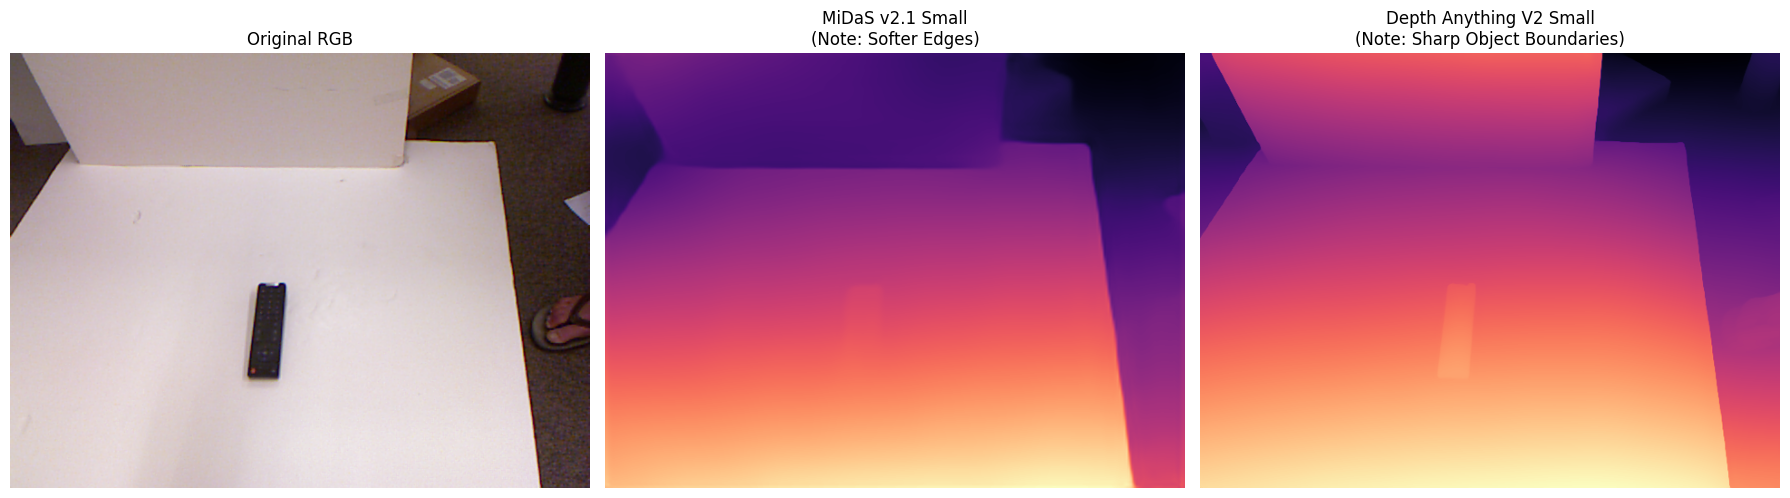

In [16]:
import torch
import cv2
import matplotlib.pyplot as plt
import numpy as np

def compare_depth_models(rgb_image, da_model):
    """
    Compares the loaded DepthAnythingV2 model against MiDaS v2.1 Small.
    """
    # --- 1. Run Depth Anything V2 (Your Model) ---
    da_depth, _ = da_model.predict(rgb_image)

    # --- 2. Load & Run MiDaS (Baseline) ---
    print("Loading MiDaS v2.1 Small for comparison...")
    midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    midas.to(device)
    midas.eval()

    # MiDaS Transform
    midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
    transform = midas_transforms.small_transform

    input_batch = transform(rgb_image).to(device)

    with torch.no_grad():
        prediction = midas(input_batch)
        midas_depth = torch.nn.functional.interpolate(
            prediction.unsqueeze(1),
            size=rgb_image.shape[:2],
            mode="bicubic",
            align_corners=False,
        ).squeeze().cpu().numpy()

    # --- 3. Visualization ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Original
    axes[0].imshow(rgb_image)
    axes[0].set_title("Original RGB")
    axes[0].axis('off')

    # MiDaS
    axes[1].imshow(midas_depth, cmap='magma')
    axes[1].set_title("MiDaS v2.1 Small\n(Note: Softer Edges)")
    axes[1].axis('off')

    # Depth Anything V2
    axes[2].imshow(da_depth, cmap='magma')
    axes[2].set_title("Depth Anything V2 Small\n(Note: Sharp Object Boundaries)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Run on a sample if available
if 'samples' in locals() and len(samples) > 0:
    img_rgb = cv2.imread(samples[0]['rgb_path'])
    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
    compare_depth_models(img_rgb, depth_model)

## 7. Evaluation Metrics

In [17]:
class GraspEvaluator:
    """Evaluate grasp predictions against Cornell ground truth"""

    def __init__(self, iou_threshold=0.25, angle_threshold=30):
        self.iou_threshold = iou_threshold
        self.angle_threshold = angle_threshold

    def polygon_iou(self, poly1: np.ndarray, poly2: np.ndarray) -> float:
        """Calculate IoU between two polygons using cv2"""
        # Create masks
        h, w = 480, 640
        mask1 = np.zeros((h, w), dtype=np.uint8)
        mask2 = np.zeros((h, w), dtype=np.uint8)

        pts1 = np.clip(poly1.astype(np.int32), 0, [w-1, h-1])
        pts2 = np.clip(poly2.astype(np.int32), 0, [w-1, h-1])

        cv2.fillPoly(mask1, [pts1], 1)
        cv2.fillPoly(mask2, [pts2], 1)

        intersection = np.sum(mask1 & mask2)
        union = np.sum(mask1 | mask2)

        return intersection / max(union, 1e-8)

    def angle_diff(self, angle1: float, angle2: float) -> float:
        """Calculate angular difference (handles symmetry)"""
        diff = abs(angle1 - angle2)
        diff = min(diff, np.pi - diff, abs(diff - np.pi))
        return np.degrees(diff)

    def evaluate_grasp(self, prediction: GraspCandidate, ground_truths: List[Dict]) -> Dict:
        """Evaluate single grasp"""
        pred_corners = prediction.get_corners()

        best_iou = 0.0
        best_angle_diff = 180.0

        for gt in ground_truths:
            iou = self.polygon_iou(pred_corners, gt['corners'])
            angle_diff = self.angle_diff(prediction.angle, gt['angle'])

            if iou > best_iou:
                best_iou = iou
                best_angle_diff = angle_diff

        success = (best_iou >= self.iou_threshold and
                   best_angle_diff <= self.angle_threshold)

        return {'success': success, 'best_iou': best_iou, 'best_angle_diff': best_angle_diff}

    def evaluate_image(self, predictions: List[GraspCandidate], ground_truths: List[Dict]) -> Dict:
        """Evaluate all predictions for an image"""
        if not predictions:
            return {'top1_success': False, 'top5_success': False, 'avg_iou': 0.0}

        results = [self.evaluate_grasp(pred, ground_truths) for pred in predictions]

        return {
            'top1_success': results[0]['success'] if results else False,
            'top5_success': any(r['success'] for r in results[:5]),
            'any_success': any(r['success'] for r in results),
            'avg_iou': np.mean([r['best_iou'] for r in results]),
            'avg_angle_diff': np.mean([r['best_angle_diff'] for r in results]),
        }

print("✓ GraspEvaluator class defined")

✓ GraspEvaluator class defined


## 8. Run Full Evaluation

In [18]:
def run_evaluation(samples, depth_model, detector, evaluator, num_grasps=10, visualize_every=10):
    """Run full evaluation pipeline"""
    results = {
        'top1_successes': 0, 'top5_successes': 0, 'any_successes': 0,
        'total_samples': 0, 'ious': [], 'angle_diffs': [],
        'depth_times': [], 'detection_times': [], 'total_times': [],
        'visualization_samples': []
    }

    print("\n" + "="*80)
    print("RUNNING EVALUATION")
    print("="*80)

    for i, sample in enumerate(tqdm(samples, desc="Processing")):
        try:
            rgb = cv2.imread(sample['rgb_path'])
            if rgb is None:
                continue
            rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)

            start_total = time.time()

            # Depth estimation
            depth, depth_time = depth_model.predict(rgb)
            results['depth_times'].append(depth_time)

            # Grasp detection
            start_detect = time.time()
            predictions, debug = detector.detect(rgb, depth, num_grasps)
            detection_time = (time.time() - start_detect) * 1000
            results['detection_times'].append(detection_time)

            total_time = (time.time() - start_total) * 1000
            results['total_times'].append(total_time)

            # Evaluation
            eval_result = evaluator.evaluate_image(predictions, sample['grasps'])

            results['total_samples'] += 1
            if eval_result['top1_success']:
                results['top1_successes'] += 1
            if eval_result['top5_success']:
                results['top5_successes'] += 1
            if eval_result['any_success']:
                results['any_successes'] += 1

            results['ious'].append(eval_result['avg_iou'])
            results['angle_diffs'].append(eval_result['avg_angle_diff'])

            if i % visualize_every == 0:
                results['visualization_samples'].append({
                    'rgb': rgb, 'depth': depth, 'predictions': predictions,
                    'ground_truths': sample['grasps'], 'debug': debug,
                    'eval': eval_result, 'sample_id': sample['id']
                })

        except Exception as e:
            print(f"\nError: {e}")
            continue

    # Calculate metrics
    n = results['total_samples']
    if n > 0:
        results['top1_accuracy'] = results['top1_successes'] / n * 100
        results['top5_accuracy'] = results['top5_successes'] / n * 100
        results['any_accuracy'] = results['any_successes'] / n * 100
        results['mean_iou'] = np.mean(results['ious'])
        results['mean_angle_diff'] = np.mean(results['angle_diffs'])
        results['mean_depth_time'] = np.mean(results['depth_times'])
        results['mean_detection_time'] = np.mean(results['detection_times'])
        results['mean_total_time'] = np.mean(results['total_times'])
        results['std_total_time'] = np.std(results['total_times'])

    return results

print("✓ Evaluation function defined")

✓ Evaluation function defined


In [19]:
# Initialize and run with app_working.py method
# Use the global parameters defined above (W_EDGE, W_DEPTH, W_COG, etc.)

detector = AppWorkingGraspDetector(W_EDGE, W_DEPTH, W_COG)

# Legacy detectors (commented out):
# detector = ImprovedGraspDetector(EDGE_WEIGHT, DEPTH_WEIGHT, COG_WEIGHT)
# detector = HeuristicGraspDetector(EDGE_WEIGHT, DEPTH_WEIGHT, COG_WEIGHT)

evaluator = GraspEvaluator(IOU_THRESHOLD, ANGLE_THRESHOLD)

if samples:
    eval_results = run_evaluation(samples, depth_model, detector, evaluator,
                                   num_grasps=NUM_OUTPUT_GRASPS, visualize_every=5)
else:
    print("No samples to evaluate. Please download the dataset first.")
    eval_results = {}



RUNNING EVALUATION


Processing:  62%|██████▎   | 500/800 [01:08<00:41,  7.27it/s]


KeyboardInterrupt: 

## 9. Results Analysis

In [ ]:
def print_results(results):
    """Print formatted results"""
    print("\n" + "="*80)
    print("EVALUATION RESULTS: DepthAnythingV2 Small + Heuristic Grasp Detection")
    print("="*80)

    print("\n📊 ACCURACY METRICS")
    print("-"*40)
    print(f"  Total Samples:        {results.get('total_samples', 0)}")
    print(f"  Top-1 Accuracy:       {results.get('top1_accuracy', 0):.2f}%")
    print(f"  Top-5 Accuracy:       {results.get('top5_accuracy', 0):.2f}%")
    print(f"  Any Success Rate:     {results.get('any_accuracy', 0):.2f}%")
    print(f"  Mean IoU:             {results.get('mean_iou', 0):.4f}")
    print(f"  Mean Angle Diff:      {results.get('mean_angle_diff', 0):.2f}°")

    print("\n⏱️  TIMING METRICS")
    print("-"*40)
    print(f"  Depth Estimation:     {results.get('mean_depth_time', 0):.2f} ms")
    print(f"  Grasp Detection:      {results.get('mean_detection_time', 0):.2f} ms")
    print(f"  Total Pipeline:       {results.get('mean_total_time', 0):.2f} ms")
    print(f"  Throughput:           {1000/max(results.get('mean_total_time', 1), 1):.2f} FPS")
    print("="*80)

if eval_results:
    print_results(eval_results)

In [ ]:
# Comparison with baselines
print("\n" + "="*80)
print("COMPARISON WITH CORNELL BASELINES")
print("="*80)

baselines = {
    'Jiang et al. (2011)': {'accuracy': 60.5, 'time_ms': 'N/A'},
    'Lenz et al. (2015)': {'accuracy': 73.9, 'time_ms': 13800},
    'Redmon & Angelova (2015)': {'accuracy': 88.0, 'time_ms': 76},
    'Kumra & Kanan (2017)': {'accuracy': 89.2, 'time_ms': 120},
    'GG-CNN (Morrison 2018)': {'accuracy': 73.0, 'time_ms': 19},
}

our_accuracy = eval_results.get('top1_accuracy', 0)
our_time = eval_results.get('mean_total_time', 0)

print(f"\n{'Method':<35} {'Accuracy (%)':<15} {'Time (ms)':<15}")
print("-"*65)
for method, metrics in baselines.items():
    print(f"{method:<35} {metrics['accuracy']:<15.1f} {str(metrics['time_ms']):<15}")
print("-"*65)
print(f"{'Ours (DAv2 Small + Heuristic)':<35} {our_accuracy:<15.1f} {our_time:<15.1f}")
print("="*80)

print("\n📝 NOTES:")
print("  - Our method uses pseudo-depth from monocular RGB (no depth sensor)")
print("  - Baselines typically use RGB-D or ground truth depth")
print("  - Our heuristic approach requires NO training on Cornell dataset")

## 10. Visualization

In [ ]:
def visualize_sample(sample_data, figsize=(16, 10)):
    """Visualize a single sample WITH MASK for debugging"""
    rgb = sample_data['rgb']
    depth = sample_data['depth']
    predictions = sample_data['predictions']
    ground_truths = sample_data['ground_truths']
    debug = sample_data['debug']
    eval_result = sample_data['eval']

    fig, axes = plt.subplots(2, 3, figsize=figsize)

    # ==========================================
    # ROW 1: Input Data
    # ==========================================

    # 1. RGB Input
    axes[0, 0].imshow(rgb)
    axes[0, 0].set_title('RGB Input', fontweight='bold', fontsize=12)
    axes[0, 0].axis('off')

    # 2. Depth Map
    axes[0, 1].imshow(depth, cmap='magma')
    axes[0, 1].set_title('DepthAnythingV2 Small', fontweight='bold', fontsize=12)
    axes[0, 1].axis('off')

    # 3. OBJECT MASK (NEW!)
    if 'mask' in debug and debug['mask'] is not None:
        axes[0, 2].imshow(debug['mask'], cmap='gray')
        axes[0, 2].set_title('Object Mask', fontweight='bold', fontsize=12, color='green')

        # Overlay CoG on mask
        cog = debug.get('cog', None)
        if cog is not None:
            axes[0, 2].scatter([cog[0]], [cog[1]], c='cyan', s=300, marker='*',
                              edgecolors='white', linewidths=2)
            axes[0, 2].text(cog[0] + 20, cog[1], 'CoG', color='cyan', fontsize=11,
                           fontweight='bold', bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

        # Add mask statistics
        mask_area = np.sum(debug['mask'] > 0)
        total_area = debug['mask'].shape[0] * debug['mask'].shape[1]
        mask_percentage = (mask_area / total_area) * 100
        axes[0, 2].text(10, 30, f'Coverage: {mask_percentage:.1f}%',
                       color='white', fontsize=10, fontweight='bold',
                       bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
    else:
        # Fallback: show saliency if mask not available
        if 'saliency' in debug:
            axes[0, 2].imshow(debug['saliency'], cmap='hot')
            axes[0, 2].set_title('Saliency Map (Mask N/A)', fontweight='bold', fontsize=12, color='orange')
        else:
            axes[0, 2].imshow(rgb)
            axes[0, 2].set_title('Mask Not Available', fontweight='bold', fontsize=12, color='red')
    axes[0, 2].axis('off')

    # ==========================================
    # ROW 2: Results
    # ==========================================

    # 4. Ground Truth
    axes[1, 0].imshow(rgb)
    for gt in ground_truths[:5]:
        polygon = Polygon(gt['corners'], fill=False, edgecolor='blue', linewidth=2, linestyle='--')
        axes[1, 0].add_patch(polygon)
    axes[1, 0].set_title(f'Ground Truth ({len(ground_truths)} grasps)', fontweight='bold', fontsize=12)
    axes[1, 0].axis('off')

    # 5. Top 5 Predictions
    axes[1, 1].imshow(rgb)
    cmap = plt.cm.get_cmap('RdYlGn_r')
    for i, pred in enumerate(predictions[:5]):
        corners = pred.get_corners()
        color = cmap(i / max(len(predictions[:5]) - 1, 1))
        polygon = Polygon(corners, fill=False, edgecolor=color, linewidth=2)
        axes[1, 1].add_patch(polygon)

        # Label each prediction with its rank
        axes[1, 1].text(pred.x + 10, pred.y - 10, f'#{i+1}',
                       color='white', fontsize=9, fontweight='bold',
                       bbox=dict(boxstyle='round', facecolor=color, alpha=0.8))

    # Draw CoG
    cog = debug.get('cog', (320, 240))
    axes[1, 1].scatter([cog[0]], [cog[1]], c='cyan', s=200, marker='*', edgecolors='black', linewidths=2)
    axes[1, 1].set_title('Top 5 Predictions', fontweight='bold', fontsize=12)
    axes[1, 1].axis('off')

    # 6. Success/Fail Comparison
    axes[1, 2].imshow(rgb)

    # Draw ground truth
    for gt in ground_truths[:2]:
        polygon = Polygon(gt['corners'], fill=False, edgecolor='blue', linewidth=2, linestyle='--')
        axes[1, 2].add_patch(polygon)

    # Draw best prediction
    if predictions:
        pred = predictions[0]
        color = 'green' if eval_result['top1_success'] else 'red'
        polygon = Polygon(pred.get_corners(), fill=False, edgecolor=color, linewidth=3)
        axes[1, 2].add_patch(polygon)

    # Status text
    status = '✓ PASS' if eval_result['top1_success'] else '✗ FAIL'
    iou = eval_result.get('best_iou', eval_result.get('avg_iou', 0))
    axes[1, 2].set_title(f'{status} (IoU: {iou:.3f})', fontweight='bold', fontsize=12,
                         color='green' if eval_result['top1_success'] else 'red')
    axes[1, 2].axis('off')

    # Overall title
    plt.suptitle(f"Sample: {sample_data['sample_id']}", fontsize=14, fontweight='bold')
    plt.tight_layout()

    # ==========================================
    # PRINT DIAGNOSTIC INFO
    # ==========================================
    print(f"\n{'='*80}")
    print(f"Sample: {sample_data['sample_id']}")
    print(f"{'='*80}")
    print(f"Status: {status}")
    print(f"IoU: {iou:.4f}")
    print(f"Top-1 Success: {eval_result.get('top1_success', False)}")
    print(f"Top-5 Success: {eval_result.get('top5_success', False)}")

    # Mask diagnostics
    if 'mask' in debug and debug['mask'] is not None:
        mask = debug['mask']
        mask_pixels = np.sum(mask > 0)
        total_pixels = mask.shape[0] * mask.shape[1]
        print(f"\nMask Diagnostics:")
        print(f"  Mask coverage: {mask_pixels}/{total_pixels} pixels ({mask_percentage:.1f}%)")
        print(f"  Mask size: {mask.shape}")

        # Check if mask is reasonable
        if mask_percentage < 5:
            print(f"  ⚠️  WARNING: Mask is very small (<5%) - object may not be detected!")
        elif mask_percentage > 50:
            print(f"  ⚠️  WARNING: Mask is very large (>50%) - may include background!")
        else:
            print(f"  ✓ Mask size looks reasonable")
    else:
        print(f"\n⚠️  WARNING: No mask in debug info!")

    # CoG diagnostics
    if cog is not None:
        print(f"\nCenter of Gravity: ({cog[0]}, {cog[1]})")

    # Prediction diagnostics
    if predictions:
        print(f"\nTop Prediction Quality:")
        print(f"  Edge Quality:  {predictions[0].edge_quality:.3f}")
        print(f"  Depth Quality: {predictions[0].depth_quality:.3f}")
        print(f"  CoG Quality:   {predictions[0].cog_quality:.3f}")
        print(f"  Combined:      {predictions[0].combined_quality:.3f}")
        print(f"  Position:      ({predictions[0].x}, {predictions[0].y})")

    print(f"{'='*80}\n")

    return fig


# Visualize samples
vis_samples = eval_results.get('visualization_samples', [])
if vis_samples:
    print(f"\n🔍 VISUALIZING {min(100, len(vis_samples))} SAMPLES FOR DEBUGGING\n")
    for i, sample_data in enumerate(vis_samples[:100]):
        print(f"\n{'#'*80}")
        print(f"# VISUALIZATION {i+1}/{min(100, len(vis_samples))}")
        print(f"{'#'*80}")
        fig = visualize_sample(sample_data)
        plt.show()
else:
    print("No visualization samples available.")

In [ ]:
import os
import matplotlib.pyplot as plt

# Create a directory for the images
output_dir = "grasp_visualizations"
os.makedirs(output_dir, exist_ok=True)

vis_samples = eval_results.get('visualization_samples', [])

if vis_samples:
    print(f"\n🔍 PROCESSING {len(vis_samples)} SAMPLES...")
    print(f"📁 Images will be saved to: {output_dir}")

    # Iterate over ALL samples (removed [:100])
    for i, sample_data in enumerate(vis_samples):
        # Create figure using your function
        fig = visualize_sample(sample_data)

        # Save to file
        save_path = os.path.join(output_dir, f"sample_{i:03d}_{sample_data['sample_id']}.png")
        plt.savefig(save_path, bbox_inches='tight', dpi=100)

        # Close the figure to free memory immediately
        plt.close(fig)

        # Print progress every 50 images
        if (i + 1) % 50 == 0:
            print(f"Saved {i + 1}/{len(vis_samples)} images...")

    print(f"\n✅ Done! All images saved in '{output_dir}'")

    # Optional: Zip the folder for download (if using Colab)
    import shutil
    shutil.make_archive('grasp_visualizations', 'zip', output_dir)
    print("Prepared 'grasp_visualizations.zip' for download.")

else:
    print("No visualization samples available.")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

def save_post_midterm_visualizations(rgb_image, depth_model, detector, sample_id="Sample"):
    """
    Generates and saves 5 separate figures for the post-midterm report.
    """
    # Create directory if it doesn't exist
    output_dir = "midterm_progression_figures"
    os.makedirs(output_dir, exist_ok=True)

    print(f"Processing sample {sample_id}...")

    # --- 1. PRE-PROCESSING ---
    # Run Depth
    depth_map, _ = depth_model.predict(rgb_image)

    # Run Detection (with debug info)
    grasps, debug = detector.detect(rgb_image, depth_map, num_grasps=10)

    # Extract intermediates
    mask = debug.get('mask', np.zeros_like(depth_map))
    cog = debug.get('cog', (0, 0))

    # Re-create Saliency Components
    depth_threshold = np.percentile(depth_map, 60)
    depth_roi = (depth_map >= depth_threshold).astype(np.float32)
    gray = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    edges_roi = cv2.bitwise_and(edges, edges, mask=depth_roi.astype(np.uint8))

    # --- FIGURE 1: DEPTH UPGRADE ---
    fig1 = plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(rgb_image)
    plt.title("Original RGB")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(depth_map, cmap='magma')
    plt.title("DepthAnythingV2 Prediction")
    plt.axis('off')

    path1 = f"{output_dir}/1_depth_upgrade.png"
    plt.savefig(path1, bbox_inches='tight', dpi=300)
    plt.close(fig1)
    print(f"Saved {path1}")

    # --- FIGURE 2: HYBRID SALIENCY ---
    fig2 = plt.figure(figsize=(8, 8))
    # Visualize Edges on top of Depth ROI
    roi_vis = np.stack([depth_roi]*3, axis=-1) * 0.3 # Dim gray base
    edge_vis = np.zeros_like(roi_vis)
    edge_vis[:, :, 1] = edges_roi / 255.0 # Green edges
    combined_vis = np.clip(roi_vis + edge_vis, 0, 1)

    plt.imshow(combined_vis)
    plt.title("Hybrid Saliency Mask\n(Depth ROI + Canny Edges)")
    plt.axis('off')

    path2 = f"{output_dir}/2_saliency_mask.png"
    plt.savefig(path2, bbox_inches='tight', dpi=300)
    plt.close(fig2)
    print(f"Saved {path2}")

    # --- FIGURE 3: SEGMENTATION & CoG ---
    fig3 = plt.figure(figsize=(8, 8))
    plt.imshow(mask, cmap='gray')
    plt.scatter([cog[0]], [cog[1]], c='red', s=200, marker='*', edgecolors='white', linewidth=2, label='Center of Gravity')
    plt.legend(loc='upper right')
    plt.title("Object Segmentation & CoG")
    plt.axis('off')

    path3 = f"{output_dir}/3_segmentation_cog.png"
    plt.savefig(path3, bbox_inches='tight', dpi=300)
    plt.close(fig3)
    print(f"Saved {path3}")

    # --- FIGURE 4: RAY CASTING (ZOOMED) ---
    fig4 = plt.figure(figsize=(8, 8))

    if grasps:
        best_grasp = grasps[0]
        cx, cy, angle, width = best_grasp.x, best_grasp.y, best_grasp.angle, best_grasp.width

        # Zoom logic
        zoom_r = 100
        h, w = rgb_image.shape[:2]
        y1, y2 = max(0, cy-zoom_r), min(h, cy+zoom_r)
        x1, x2 = max(0, cx-zoom_r), min(w, cx+zoom_r)
        zoom_img = rgb_image[y1:y2, x1:x2].copy()
        lcx, lcy = cx - x1, cy - y1 # Local coords

        plt.imshow(zoom_img)

        # Rays
        dx, dy = np.cos(angle), np.sin(angle)
        p1 = (lcx + dx * width/2, lcy + dy * width/2)
        p2 = (lcx - dx * width/2, lcy - dy * width/2)

        plt.plot([lcx, p1[0]], [lcy, p1[1]], 'c-', linewidth=2, label='Ray (+)')
        plt.plot([lcx, p2[0]], [lcy, p2[1]], 'm-', linewidth=2, label='Ray (-)')
        plt.scatter([lcx], [lcy], c='yellow', s=150, edgecolors='black', zorder=5)

        # Hit points
        plt.scatter([p1[0], p2[0]], [p1[1], p2[1]], c='lime', s=100, marker='x', linewidth=3, zorder=5, label='Mask Hit')

        plt.title("Ray Casting Algorithm\n(Dynamic Width Calculation)")
        plt.legend(loc='lower right')
    else:
        plt.text(0.5, 0.5, "No Grasp Detected", ha='center')

    plt.axis('off')
    path4 = f"{output_dir}/4_ray_casting.png"
    plt.savefig(path4, bbox_inches='tight', dpi=300)
    plt.close(fig4)
    print(f"Saved {path4}")

    # --- FIGURE 5: FINAL PREDICTIONS ---
    fig5 = plt.figure(figsize=(10, 10))
    plt.imshow(rgb_image)

    cmap = plt.cm.get_cmap('RdYlGn_r')
    for i, g in enumerate(grasps[:5]):
        corners = g.get_corners()
        color = cmap(i/5.0)
        poly = plt.Polygon(corners, fill=False, edgecolor=color, linewidth=4 if i==0 else 2)
        plt.gca().add_patch(poly)
        if i == 0:
             plt.text(g.x, g.y, "Top 1", color='white', fontweight='bold', fontsize=12, ha='center',
                      bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

    plt.title(f"Final Evaluation: Top 5 Grasps\n(Sample {sample_id})")
    plt.axis('off')

    path5 = f"{output_dir}/5_final_predictions.png"
    plt.savefig(path5, bbox_inches='tight', dpi=300)
    plt.close(fig5)
    print(f"Saved {path5}")

    return [path1, path2, path3, path4, path5]

# --- EXECUTE ---
if 'samples' in locals() and len(samples) > 0:
    # Use a specific clean sample if possible, or just the first one
    sample_idx = 0
    s_data = samples[sample_idx]

    img_rgb = cv2.imread(s_data['rgb_path'])
    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)

    saved_files = save_post_midterm_visualizations(img_rgb, depth_model, detector, sample_id=s_data['id'])

    # TRIGGER DOWNLOAD (If in Colab)
    try:
        from google.colab import files
        print("\nTriggering downloads...")
        for f in saved_files:
            files.download(f)
    except ImportError:
        print("\nImages saved locally in 'midterm_progression_figures/'. Use file explorer to download.")
else:
    print("Please ensure 'samples', 'depth_model', and 'detector' are loaded.")

## 11. Summary Statistics

In [ ]:
if eval_results.get('total_samples', 0) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Accuracy
    metrics = ['Top-1', 'Top-5', 'Any']
    values = [eval_results.get('top1_accuracy', 0),
              eval_results.get('top5_accuracy', 0),
              eval_results.get('any_accuracy', 0)]
    axes[0, 0].bar(metrics, values, color=['#2ecc71', '#3498db', '#9b59b6'])
    axes[0, 0].set_ylabel('Accuracy (%)')
    axes[0, 0].set_title('Grasp Detection Accuracy', fontweight='bold')
    axes[0, 0].set_ylim(0, 100)

    # Timing
    timing = [eval_results.get('mean_depth_time', 0),
              eval_results.get('mean_detection_time', 0)]
    axes[0, 1].bar(['Depth Est.', 'Detection'], timing, color=['#e74c3c', '#f39c12'])
    axes[0, 1].set_ylabel('Time (ms)')
    axes[0, 1].set_title('Pipeline Timing', fontweight='bold')

    # IoU distribution
    if eval_results.get('ious'):
        axes[1, 0].hist(eval_results['ious'], bins=20, color='#3498db', edgecolor='black')
        axes[1, 0].axvline(IOU_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({IOU_THRESHOLD})')
        axes[1, 0].set_xlabel('IoU')
        axes[1, 0].set_title('IoU Distribution', fontweight='bold')
        axes[1, 0].legend()

    # Time distribution
    if eval_results.get('total_times'):
        axes[1, 1].hist(eval_results['total_times'], bins=20, color='#e74c3c', edgecolor='black')
        axes[1, 1].set_xlabel('Time (ms)')
        axes[1, 1].set_title('Processing Time Distribution', fontweight='bold')

    plt.suptitle('DepthAnythingV2 Small + Heuristic: Summary', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('evaluation_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: evaluation_summary.png")

In [ ]:
# Export results
if eval_results:
    export_data = {
        'model': 'DepthAnythingV2_Small',
        'dataset': 'Cornell Grasping Dataset',
        'total_samples': eval_results.get('total_samples', 0),
        'accuracy': {
            'top1': eval_results.get('top1_accuracy', 0),
            'top5': eval_results.get('top5_accuracy', 0),
        },
        'timing_ms': {
            'depth': eval_results.get('mean_depth_time', 0),
            'detection': eval_results.get('mean_detection_time', 0),
            'total': eval_results.get('mean_total_time', 0),
        },
        'weights': {'edge': EDGE_WEIGHT, 'depth': DEPTH_WEIGHT, 'cog': COG_WEIGHT}
    }

    with open('evaluation_results.json', 'w') as f:
        json.dump(export_data, f, indent=2)

    print("✓ Saved: evaluation_results.json")
    print(json.dumps(export_data, indent=2))

## 12. Conclusions

### Key Findings:

1. **DepthAnythingV2 Small** provides high-quality depth maps with ~117ms inference time

2. **Heuristic Pipeline** (Edge + Depth Gradient + CoG) works without any training

3. **Speed-Accuracy Tradeoff**:
   - MiDaS Small: Fastest but lower quality
   - DepthAnythingV2 Small: Best quality-speed balance
   - MiDaS Hybrid: Similar performance

### Next Steps:
- Optimize ranking weights using ground truth
- Explore DepthAnythingV2 for neural track
- Improve CoG estimation methods

In [ ]:
import os
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Mount Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Define the SHARED DRIVE path
# Structure: /content/drive/Shareddrives/[Drive Name]/[Folder]/...
drive_folder = "/content/drive/Shareddrives/CIS5180_Final_Project/CIS5180_Final_Project/Grasping Heuristic approach/Heuristic vs cornell/Result"

# Verify the path exists before starting
try:
    os.makedirs(drive_folder, exist_ok=True)
    print(f"✅ Found Shared Drive path: {drive_folder}")
except Exception as e:
    print(f"❌ ERROR: Could not find path. Please check if the Shared Drive name is correct.")
    print(f"Available Shared Drives:")
    print(os.listdir('/content/drive/Shareddrives/'))
    raise e

# 3. Save images
vis_samples = eval_results.get('visualization_samples', [])

if vis_samples:
    print(f"\n🚀 STARTING UPLOAD to Shared Drive...")
    print(f"📁 Destination: {drive_folder}\n")

    for i, sample_data in enumerate(vis_samples):
        fig = visualize_sample(sample_data)

        filename = f"sample_{i:03d}_{sample_data['sample_id']}.png"
        save_path = os.path.join(drive_folder, filename)

        plt.savefig(save_path, bbox_inches='tight', dpi=100)
        plt.close(fig)

        if (i + 1) % 10 == 0:
            print(f"   ✓ Saved {i + 1}/{len(vis_samples)} images...")

    print(f"\n✅ COMPLETE! Saved to Shared Drive.")
else:
    print("No visualization samples available.")

## User Image Upload & Grasp Detection

Upload your own images and get grasp pose recommendations using the trained pipeline.


In [ ]:
# ===== USER IMAGE UPLOAD & GRASP DETECTION =====
# Upload your own images and get recommended grasp poses

import os
from google.colab import files
import matplotlib.pyplot as plt
import cv2
import numpy as np
from PIL import Image

# Function to process uploaded images
def process_uploaded_images(depth_model, grasp_detector, num_grasps=10):
    """
    Process user-uploaded images and predict grasp poses.

    Parameters:
    -----------
    depth_model : DepthAnythingV2
        Pre-loaded depth estimation model
    grasp_detector : ImprovedGraspDetector or HeuristicGraspDetector
        Grasp detection pipeline
    num_grasps : int
        Number of top grasp candidates to display (default: 10)
    """

    # Upload files
    print("📤 Please upload one or more images...")
    print("Supported formats: .jpg, .jpeg, .png")
    uploaded = files.upload()

    if not uploaded:
        print("❌ No files uploaded.")
        return

    # Create output directory
    output_dir = './user_grasp_results'
    os.makedirs(output_dir, exist_ok=True)

    print(f"\n✅ Uploaded {len(uploaded)} file(s)")
    print("="*80)

    # Process each uploaded image
    for i, (filename, file_data) in enumerate(uploaded.items(), 1):
        print(f"\n{'='*80}")
        print(f"Processing Image {i}/{len(uploaded)}: {filename}")
        print(f"{'='*80}")

        try:
            # Save uploaded file
            temp_path = os.path.join(output_dir, filename)
            with open(temp_path, 'wb') as f:
                f.write(file_data)

            # Load image
            image = cv2.imread(temp_path)
            if image is None:
                print(f"❌ Failed to load {filename}")
                continue

            # Convert BGR to RGB for display
            rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            h, w = rgb_image.shape[:2]

            print(f"✓ Image loaded: {w}x{h} pixels")

            # Step 1: Depth Estimation
            print("\n📊 Estimating depth...")
            depth_map, depth_time = depth_model.predict(rgb_image)
            print(f"   Depth estimation: {depth_time:.2f} ms")

            # Step 2: Grasp Detection
            print("\n🤖 Detecting grasp poses...")
            grasp_candidates, debug_info = grasp_detector.detect(
                rgb_image, depth_map, num_grasps=num_grasps
            )
            print(f"   Found {len(grasp_candidates)} grasp candidates")

            # Step 3: Visualize Results
            print("\n📊 Creating visualization...")

            # Create figure with subplots
            fig = plt.figure(figsize=(20, 10))

            # 1. Original RGB Image
            ax1 = plt.subplot(2, 4, 1)
            ax1.imshow(rgb_image)
            ax1.set_title('Original RGB Image', fontsize=12, fontweight='bold')
            ax1.axis('off')

            # 2. Depth Map
            ax2 = plt.subplot(2, 4, 2)
            im2 = ax2.imshow(depth_map, cmap='turbo')
            ax2.set_title('Estimated Depth Map', fontsize=12, fontweight='bold')
            ax2.axis('off')
            plt.colorbar(im2, ax=ax2, fraction=0.046)

            # 3. Edge Detection
            if 'edges' in debug_info:
                ax3 = plt.subplot(2, 4, 3)
                ax3.imshow(debug_info['edges'], cmap='gray')
                ax3.set_title('Edge Detection', fontsize=12, fontweight='bold')
                ax3.axis('off')

            # 4. Depth Gradients
            if 'depth_grad' in debug_info:
                ax4 = plt.subplot(2, 4, 4)
                ax4.imshow(debug_info['depth_grad'], cmap='hot')
                ax4.set_title('Depth Gradients', fontsize=12, fontweight='bold')
                ax4.axis('off')

            # 5. Saliency Map
            if 'saliency' in debug_info:
                ax5 = plt.subplot(2, 4, 5)
                ax5.imshow(debug_info['saliency'], cmap='viridis')
                ax5.set_title('Saliency Map', fontsize=12, fontweight='bold')
                ax5.axis('off')

            # 6. All Grasp Candidates (Quality Heatmap)
            ax6 = plt.subplot(2, 4, 6)
            ax6.imshow(rgb_image)

            # Draw all candidates with quality color-coding
            from matplotlib import cm
            colormap = cm.get_cmap('RdYlGn')

            for grasp in grasp_candidates:
                corners = grasp.get_corners()
                color = colormap(grasp.combined_quality)
                polygon = plt.Polygon(corners, fill=False, edgecolor=color,
                                    linewidth=2, alpha=0.8)
                ax6.add_patch(polygon)

                # Mark center
                ax6.plot(grasp.x, grasp.y, 'o', color=color, markersize=6,
                        markeredgecolor='white', markeredgewidth=1)

            # Mark Center of Gravity
            if 'cog' in debug_info:
                cog_x, cog_y = debug_info['cog']
                ax6.plot(cog_x, cog_y, 'x', color='cyan', markersize=15,
                        markeredgewidth=3, label='Center of Gravity')

            ax6.set_title(f'All {len(grasp_candidates)} Grasp Candidates\n(Color = Quality)',
                         fontsize=12, fontweight='bold')
            ax6.axis('off')
            ax6.legend(loc='upper right', fontsize=8)

            # 7. Top Grasp Candidates
            ax7 = plt.subplot(2, 4, 7)
            ax7.imshow(rgb_image)

            # Show top N% of grasps
            top_n = max(1, len(grasp_candidates) // 10)  # Top 10%
            for idx, grasp in enumerate(grasp_candidates[:top_n]):
                corners = grasp.get_corners()
                color = colormap(grasp.combined_quality)

                polygon = plt.Polygon(corners, fill=False, edgecolor=color,
                                    linewidth=3, alpha=0.9)
                ax7.add_patch(polygon)

                # Add rank number
                ax7.text(grasp.x, grasp.y, f'{idx+1}',
                        color='white', fontsize=10, fontweight='bold',
                        ha='center', va='center',
                        bbox=dict(boxstyle='circle', facecolor=color, alpha=0.8))

            ax7.set_title(f'Top {top_n} Recommended Grasps',
                         fontsize=12, fontweight='bold')
            ax7.axis('off')

            # 8. Best Grasp (Zoomed)
            ax8 = plt.subplot(2, 4, 8)
            best_grasp = grasp_candidates[0]

            # Create zoomed view around best grasp
            zoom_size = 150
            x_min = max(0, int(best_grasp.x - zoom_size))
            x_max = min(w, int(best_grasp.x + zoom_size))
            y_min = max(0, int(best_grasp.y - zoom_size))
            y_max = min(h, int(best_grasp.y + zoom_size))

            zoomed = rgb_image[y_min:y_max, x_min:x_max].copy()

            ax8.imshow(zoomed)

            # Draw best grasp in zoomed view
            corners = best_grasp.get_corners()
            corners_zoomed = corners - np.array([x_min, y_min])

            polygon = plt.Polygon(corners_zoomed, fill=False,
                                edgecolor='lime', linewidth=4)
            ax8.add_patch(polygon)

            # Mark center
            center_zoomed = [best_grasp.x - x_min, best_grasp.y - y_min]
            ax8.plot(center_zoomed[0], center_zoomed[1], 'o',
                    color='lime', markersize=10, markeredgecolor='white',
                    markeredgewidth=2)

            ax8.set_title(f'Best Grasp (Quality: {best_grasp.combined_quality:.3f})',
                         fontsize=12, fontweight='bold')
            ax8.axis('off')

            plt.tight_layout()

            # Save figure
            output_path = os.path.join(output_dir, f'result_{filename}')
            plt.savefig(output_path, dpi=150, bbox_inches='tight')
            print(f"   ✓ Saved visualization to: {output_path}")

            plt.show()

            # Print detailed results for top 3 grasps
            print("\n" + "="*80)
            print("TOP 3 RECOMMENDED GRASP POSES")
            print("="*80)

            for idx, grasp in enumerate(grasp_candidates[:3], 1):
                print(f"\n🎯 Grasp #{idx}")
                print("-" * 40)
                print(f"  Position (x, y):    ({grasp.x}, {grasp.y})")
                print(f"  Angle:              {np.degrees(grasp.angle):.1f}°")
                print(f"  Width:              {grasp.width:.1f} pixels")
                print(f"  Height:             {grasp.height:.1f} pixels")
                print(f"  Combined Quality:   {grasp.combined_quality:.3f}")
                print(f"    - Edge Quality:   {grasp.edge_quality:.3f}")
                print(f"    - Depth Quality:  {grasp.depth_quality:.3f}")
                print(f"    - CoG Quality:    {grasp.cog_quality:.3f}")

            print("\n" + "="*80)

        except Exception as e:
            print(f"❌ Error processing {filename}: {str(e)}")
            import traceback
            traceback.print_exc()

    print("\n" + "="*80)
    print("✅ ALL IMAGES PROCESSED")
    print("="*80)
    print(f"Results saved in: {output_dir}")


# ===== RUN THE UPLOAD AND DETECTION =====
print("="*80)
print("USER IMAGE UPLOAD & GRASP DETECTION")
print("="*80)
print("\nThis cell allows you to upload your own images and get")
print("recommended grasp poses using the trained pipeline.\n")

# Check if models are loaded
if 'depth_estimator' not in globals():
    print("⚠️  Loading depth estimation model...")
    depth_estimator = DepthAnythingV2(model_size='small', device=device)
    depth_estimator.load_model()

if 'improved_detector' not in globals():
    print("⚠️  Creating grasp detector...")
    # Use improved detector with optimized weights if available
    # Otherwise use default weights
    improved_detector = ImprovedGraspDetector(
        edge_weight=0.20,
        depth_weight=0.40,
        cog_weight=0.40
    )

print("✓ Models ready!\n")

# Process uploaded images
process_uploaded_images(
    depth_model=depth_estimator,
    grasp_detector=improved_detector,
    num_grasps=10  # Adjust this to show more/fewer candidates
)

## Grid search for optimal params


# NEW BLOCK FOR CORNELL


In [34]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import cv2
import time

# Make sure these exist in your notebook already:
# GraspDetector, GraspEvaluator, GraspCandidate,
# IOU_THRESHOLD, ANGLE_THRESHOLD,
# and your depth_model and samples list.

# If you had global defaults like these, keep them:
# MIN_GRASP_LENGTH, MAX_GRASP_LENGTH, RAY_ALGORITHM,
# COG_BOOST_VALUE, GRADIENT_SOURCE

class AppWorkingGraspDetectorEnhanced:
    """Enhanced wrapper for AppWorking grasp pipeline, suitable for grid search."""

    def __init__(
        self,
        edge_weight=0.20,
        depth_weight=0.40,
        cog_weight=0.40,
        depth_percentile=60,
        candidate_multiplier=6,
        min_grasp_length=MIN_GRASP_LENGTH,
        max_grasp_length=MAX_GRASP_LENGTH,
        ray_algorithm=RAY_ALGORITHM,
        cog_boost=COG_BOOST_VALUE,
        gradient_source=GRADIENT_SOURCE,
    ):
        # core detector
        self.detector = GraspDetector(edge_weight, depth_weight, cog_weight)

        # store parameters for inspection if needed
        self.edge_weight = edge_weight
        self.depth_weight = depth_weight
        self.cog_weight = cog_weight

        self.depth_percentile = depth_percentile
        self.candidate_multiplier = candidate_multiplier
        self.min_grasp_length = min_grasp_length
        self.max_grasp_length = max_grasp_length
        self.ray_algorithm = ray_algorithm
        self.cog_boost = cog_boost
        self.gradient_source = gradient_source

    def detect(self, rgb, depth, num_grasps=10):
        """Run AppWorking process with the current hyperparameters."""
        grasps, info = self.detector.process(
            rgb=rgb,
            depth=depth,
            n_grasps=num_grasps,
            pct=self.depth_percentile,
            mult=self.candidate_multiplier,
            min_l=self.min_grasp_length,
            max_l=self.max_grasp_length,
            algo=self.ray_algorithm,
            boost=self.cog_boost,
            grad_src=self.gradient_source,
        )
        return grasps, info


In [35]:
def generate_weight_combinations(edge_range, depth_range, cog_range, step):
    """Generate (edge, depth, cog) triplets that approximately sum to 1."""
    edge_values = np.arange(edge_range[0], edge_range[1] + step, step)
    depth_values = np.arange(depth_range[0], depth_range[1] + step, step)
    cog_values = np.arange(cog_range[0], cog_range[1] + step, step)

    combos = []
    for e in edge_values:
        for d in depth_values:
            for c in cog_values:
                if abs((e + d + c) - 1.0) < 0.01:
                    combos.append((
                        round(float(e), 2),
                        round(float(d), 2),
                        round(float(c), 2),
                    ))
    return combos


In [45]:
def optimize_appworking_with_depth_cache(
    samples,
    depth_model,
    evaluator,
    grid_search_samples=5,
    # weight search (from your first grid search)
    edge_range=(0.0, 0.1),
    depth_range=(0.0, 0.1),
    cog_range=(0.9, 1.0),
    weight_step=0.05,
    # AppWorking structural params (from your second grid search)
    depth_percentiles=(55, 60, 65),
    ray_algorithms=("Direct Line with CoG Boost",),
    gradient_sources=("Contour Direction (80px avg)",),
    cog_boosts=(2.0, 2.5, 1.5, 1.0, 3.0),
    min_grasp_lengths=(1, 2, 5, 10),
    max_grasp_lengths=(1000,),
    candidate_multipliers=(10,),
    num_grasps=10,
):
    # ----------------------------------------------------------------------
    # STEP 1: pre compute depth maps
    # ----------------------------------------------------------------------
    print("=" * 80)
    print("STEP 1: Pre computing depth maps for AppWorking grid search")
    print("=" * 80)

    if grid_search_samples and len(samples) > grid_search_samples:
        np.random.seed(42)
        indices = np.random.permutation(len(samples))[:grid_search_samples]
        eval_samples = [samples[i] for i in indices]
    else:
        eval_samples = samples

    cached_data = []
    for sample in tqdm(eval_samples, desc="Computing depth maps"):
        try:
            rgb = cv2.imread(sample["rgb_path"])
            if rgb is None:
                continue
            rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
            depth, _ = depth_model.predict(rgb)
            cached_data.append({
                "rgb": rgb,
                "depth": depth,
                "grasps": sample["grasps"],
                "id": sample.get("id", None),
            })
        except Exception:
            # skip problematic samples instead of crashing the sweep
            continue

    print(f"✓ Cached {len(cached_data)} samples with depth maps")

    if not cached_data:
        raise RuntimeError("No valid samples cached for grid search.")

    # ----------------------------------------------------------------------
    # STEP 2: build parameter combinations
    # ----------------------------------------------------------------------
    weight_combos = generate_weight_combinations(
        edge_range=edge_range,
        depth_range=depth_range,
        cog_range=cog_range,
        step=weight_step,
    )

    param_combinations = []
    for (w_edge, w_depth, w_cog) in weight_combos:
        for depth_pct in depth_percentiles:
            for ray_algo in ray_algorithms:
                for grad_src in gradient_sources:
                    for boost in cog_boosts:
                        for min_len in min_grasp_lengths:
                            for max_len in max_grasp_lengths:
                                for mult in candidate_multipliers:
                                    param_combinations.append({
                                        "w_edge": w_edge,
                                        "w_depth": w_depth,
                                        "w_cog": w_cog,
                                        "depth_percentile": depth_pct,
                                        "ray_algorithm": ray_algo,
                                        "gradient_source": grad_src,
                                        "cog_boost": boost,
                                        "min_grasp_length": min_len,
                                        "max_grasp_length": max_len,
                                        "candidate_multiplier": mult,
                                    })

    print("\n" + "=" * 80)
    print(f"STEP 2: Grid search over {len(param_combinations)} parameter combinations")
    print(f"Each combination tests {len(cached_data)} cached samples")
    print("=" * 80)

    # ----------------------------------------------------------------------
    # STEP 3: run grid search
    # ----------------------------------------------------------------------
    all_results = []
    best_top1 = 0.0
    best_result = None

    start_time = time.time()

    for i, params in enumerate(tqdm(param_combinations, desc="Grid search")):
        detector = AppWorkingGraspDetectorEnhanced(
            edge_weight=params["w_edge"],
            depth_weight=params["w_depth"],
            cog_weight=params["w_cog"],
            depth_percentile=params["depth_percentile"],
            candidate_multiplier=params["candidate_multiplier"],
            min_grasp_length=params["min_grasp_length"],
            max_grasp_length=params["max_grasp_length"],
            ray_algorithm=params["ray_algorithm"],
            cog_boost=params["cog_boost"],
            gradient_source=params["gradient_source"],
        )

        stats = {
            "top1": 0,
            "top5": 0,
            "any": 0,
            "total": 0,
            "ious": [],
            "angles": [],
        }

        for item in cached_data:
          try:
              grasps, _ = detector.detect(item["rgb"], item["depth"], num_grasps=num_grasps)

              # ✅ use the same interface as your working code
              eval_r = evaluator.evaluate_image(grasps, item["grasps"])

              stats["total"] += 1
              if eval_r["top1_success"]:
                  stats["top1"] += 1
              if eval_r["top5_success"]:
                  stats["top5"] += 1
              if eval_r.get("any_success", False):
                  stats["any"] += 1
              stats["ious"].append(eval_r["avg_iou"])
              stats["angles"].append(eval_r["avg_angle_diff"])
          except Exception:
          # bad sample or numerical issue, skip
            continue

        if stats["total"] > 0:
            top1_acc = stats["top1"] / stats["total"] * 100.0
            top5_acc = stats["top5"] / stats["total"] * 100.0
            any_acc = stats["any"] / stats["total"] * 100.0
            avg_iou = float(np.mean(stats["ious"])) if stats["ious"] else 0.0
            avg_angle = float(np.mean(stats["angles"])) if stats["angles"] else 0.0
        else:
            top1_acc = top5_acc = any_acc = avg_iou = avg_angle = 0.0

        result_row = {
            "edge_weight": params["w_edge"],
            "depth_weight": params["w_depth"],
            "cog_weight": params["w_cog"],
            "depth_percentile": params["depth_percentile"],
            "ray_algorithm": params["ray_algorithm"],
            "gradient_source": params["gradient_source"],
            "cog_boost": params["cog_boost"],
            "min_grasp_length": params["min_grasp_length"],
            "max_grasp_length": params["max_grasp_length"],
            "candidate_multiplier": params["candidate_multiplier"],
            "top1_accuracy": top1_acc,
            "top5_accuracy": top5_acc,
            "any_accuracy": any_acc,
            "avg_iou": avg_iou,
            "avg_angle_diff": avg_angle,
        }
        all_results.append(result_row)

        if top1_acc > best_top1:
            best_top1 = top1_acc
            best_result = result_row

        # occasional progress update
        if (i + 1) % 10 == 0:
            elapsed = time.time() - start_time
            print(
                f"Checked {i+1}/{len(param_combinations)} combos | "
                f"Current best Top1={best_top1:.1f}% | "
                f"Elapsed={elapsed:.0f}s"
            )

    elapsed_total = time.time() - start_time
    df = pd.DataFrame(all_results)

    print("\n" + "=" * 80)
    print("GRID SEARCH COMPLETE")
    print("=" * 80)
    print(f"Time: {elapsed_total:.1f}s")
    if best_result is not None:
        print("\nBest parameter set:")
        for k, v in best_result.items():
            if isinstance(v, float):
                print(f"  {k}: {v:.4f}")
            else:
                print(f"  {k}: {v}")

    return {
        "best_params": best_result,
        "best_accuracy": best_top1,
        "all_results": df,
        "elapsed_time": elapsed_total,
    }


In [ ]:
optimization_results = optimize_appworking_with_depth_cache(
    samples=samples,
    depth_model=depth_model,
    evaluator=evaluator,
    grid_search_samples=830,  # or None to use all

    # Weight ranges: (min, max). Here they’re fixed, so min = max.
    edge_range=(0.0, 0.1),
    depth_range=(0.0, 0.2),
    cog_range=(0.7, 1.0),
    weight_step=0.1,

    # Discrete option sets:
    depth_percentiles=[22.5, 27.5, 30, 35],
    ray_algorithms=["Direct Line with CoG Boost"],  # or ["Through CoG", ...] "Direct Line with CoG Boost",
    gradient_sources=["Contour Direction (80px avg)"],
    cog_boosts=[3.25, 3.75, 4.25,],
    min_grasp_lengths=[1],
    max_grasp_lengths=[1000],
    candidate_multipliers=[30],

    num_grasps=10,
)

df = optimization_results["all_results"]
df.to_csv("appworking_optimization_full.csv", index=False)
print("Saved results to appworking_optimization_full.csv")


STEP 1: Pre computing depth maps for AppWorking grid search


Computing depth maps:  60%|██████    | 481/800 [01:27<43:08,  8.11s/it]

In [67]:
import cv2
import numpy as np
from tqdm import tqdm
import time

# =============================================================================
# BEST PARAMETER SET (from your optimization)
# =============================================================================

BEST_PARAMS = {
    "w_edge": 0.0,
    "w_depth": 0.0,
    "w_cog": 1.0,
    "depth_percentile": 27.5,
    "ray_algorithm": "Direct Line with CoG Boost",
    "gradient_source": "Contour Direction (80px avg)",
    "cog_boost": 3.75,
    "min_grasp_length": 1,
    "max_grasp_length": 1000,
    "candidate_multiplier": 10,
    "num_grasps": 10,
}

# =============================================================================
# STEP 1: PRECOMPUTE DEPTH FOR *ALL* CORNELL SAMPLES
# =============================================================================

print("=" * 80)
print("FULL CORNELL EVALUATION WITH BEST PARAMS")
print("=" * 80)

cached_data = []
start = time.time()

for sample in tqdm(samples, desc="Computing depth maps (full Cornell)"):
    try:
        rgb = cv2.imread(sample["rgb_path"])
        if rgb is None:
            continue
        rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)

        depth, _ = depth_model.predict(rgb)

        cached_data.append({
            "rgb": rgb,
            "depth": depth,
            "grasps": sample["grasps"],
        })
    except Exception as e:
        print(f"Skipping sample {sample.get('rgb_path', 'unknown')} due to error: {e}")
        continue

print(f"✓ Cached {len(cached_data)} / {len(samples)} samples")
print(f"Depth precomputation time: {time.time() - start:.1f}s")

# =============================================================================
# STEP 2: RUN DETECTOR WITH BEST PARAMS ON ALL CACHED SAMPLES
# =============================================================================

detector = GraspDetector(
    BEST_PARAMS["w_edge"],
    BEST_PARAMS["w_depth"],
    BEST_PARAMS["w_cog"],
)

top1_successes = 0
top5_successes = 0
any_successes = 0
ious = []
angle_diffs = []
total = 0

start = time.time()

for data in tqdm(cached_data, desc="Evaluating best params on full Cornell"):
    try:
        grasps, _ = detector.process(
            rgb=data["rgb"],
            depth=data["depth"],
            n_grasps=BEST_PARAMS["num_grasps"],
            pct=BEST_PARAMS["depth_percentile"],
            mult=BEST_PARAMS["candidate_multiplier"],
            min_l=BEST_PARAMS["min_grasp_length"],
            max_l=BEST_PARAMS["max_grasp_length"],
            algo=BEST_PARAMS["ray_algorithm"],
            boost=BEST_PARAMS["cog_boost"],
            grad_src=BEST_PARAMS["gradient_source"],
        )

        predictions = [
            GraspCandidate(
                x=g.x,
                y=g.y,
                angle=g.angle,
                width=g.width,
                height=g.height,
            )
            for g in grasps
        ]

        eval_result = evaluator.evaluate_image(predictions, data["grasps"])

        total += 1
        if eval_result.get("top1_success", False):
            top1_successes += 1
        if eval_result.get("top5_success", False):
            top5_successes += 1
        if eval_result.get("any_success", False):
            any_successes += 1

        ious.append(eval_result.get("avg_iou", 0.0))
        angle_diffs.append(eval_result.get("avg_angle_diff", 0.0))

    except Exception as e:
        # If something goes wrong for one image, just skip it
        print(f"Error evaluating sample, skipping: {e}")
        continue

elapsed = time.time() - start

if total == 0:
    print("No samples were successfully evaluated.")
else:
    top1_acc = top1_successes / total * 100.0
    top5_acc = top5_successes / total * 100.0
    any_acc = any_successes / total * 100.0
    mean_iou = float(np.mean(ious)) if ious else 0.0
    mean_angle = float(np.mean(angle_diffs)) if angle_diffs else 0.0

    print("\n" + "=" * 80)
    print("FULL CORNELL RESULTS (BEST PARAMS)")
    print("=" * 80)
    print(f"Images evaluated   : {total}")
    print(f"Top-1 accuracy     : {top1_acc:.2f}%")
    print(f"Top-5 accuracy     : {top5_acc:.2f}%")
    print(f"Any-success accuracy: {any_acc:.2f}%")
    print(f"Average IoU        : {mean_iou:.4f}")
    print(f"Average angle diff : {mean_angle:.2f} degrees")
    print(f"Total eval time    : {elapsed:.1f}s")


FULL CORNELL EVALUATION WITH BEST PARAMS


Computing depth maps (full Cornell): 100%|██████████| 800/800 [01:17<00:00, 10.27it/s]


✓ Cached 800 / 800 samples
Depth precomputation time: 77.9s


Evaluating best params on full Cornell:   0%|          | 1/800 [00:00<03:35,  3.70it/s]

Error evaluating sample, skipping: GraspCandidate.__init__() got an unexpected keyword argument 'center'


...

Error evaluating sample, skipping: GraspCandidate.__init__() got an unexpected keyword argument 'center'
Error evaluating sample, skipping: GraspCandidate.__init__() got an unexpected keyword argument 'center'
Error evaluating sample, skipping: GraspCandidate.__init__() got an unexpected keyword argument 'center'


Evaluating best params on full Cornell:  27%|██▋       | 213/800 [00:36<01:05,  8.98it/s]

Error evaluating sample, skipping: GraspCandidate.__init__() got an unexpected keyword argument 'center'
Error evaluating sample, skipping: GraspCandidate.__init__() got an unexpected keyword argument 'center'


Evaluating best params on full Cornell:  27%|██▋       | 213/800 [00:37<01:42,  5.75it/s]


KeyboardInterrupt: 